In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
rt = pd.read_parquet("../data/processed/rt_detailed.parquet")
rt2 = pd.read_parquet("../data/processed/rt_detailed2.parquet")
print(rt.shape)
print(rt2.shape)

(225358, 30)
(13774106, 30)


Number of duplicate (AssignmentID, Timestamp)

In [3]:
print(f"Num Duplicates: {rt2[rt2["Time_Delta_sec"] == 0].shape[0]}")

Num Duplicates: 13058525


In [4]:
rt2 = rt2[rt2["Time_Delta_sec"] != 0]
rt2.head(10)

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
0,PickPut,102,5,4181343,13648,9,2023-10-05 11:59:33,100298,NaT,<NA>,...,<NA>,<NA>,<NA>,233,233,NaN,NaN,233:233,NaN,NaN
5,PickPut,102,5,4181343,13577,6,2023-10-05 12:00:26,100298,2023-10-05 11:59:33,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
10,PickPut,102,5,4183975,24252,10,2023-10-06 11:58:38,100298,2023-10-05 12:00:26,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
15,PickPut,102,5,4183975,13577,10,2023-10-06 11:58:48,100298,2023-10-06 11:58:38,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
20,PickPut,102,5,4184115,13782,504,2023-10-06 17:24:53,100298,2023-10-06 11:58:48,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
26,PickPut,102,5,4184115,13761,48,2023-10-06 17:25:04,100298,2023-10-06 17:24:53,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
32,PickPut,102,5,4185591,25565,300,2023-10-07 11:39:32,116855,2023-10-06 17:25:04,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0
46,PickPut,102,5,4185357,13795,750,2023-10-07 13:51:27,116855,2023-10-07 11:39:32,116855,...,233,20,<NA>,233,233,233,233,233:233,233:233,0.0
60,PickPut,102,5,4185523,15728,15,2023-10-07 14:05:15,100298,2023-10-07 13:51:27,116855,...,233,20,<NA>,233,233,233,233,233:233,233:233,0.0
74,PickPut,102,5,4187554,13287,20,2023-10-10 12:51:37,116855,2023-10-07 14:05:15,100298,...,233,10,<NA>,233,233,233,233,233:233,233:233,0.0


Text(0.5, 1.0, 'Number of Distinct Timestamps Recorded in a Day')

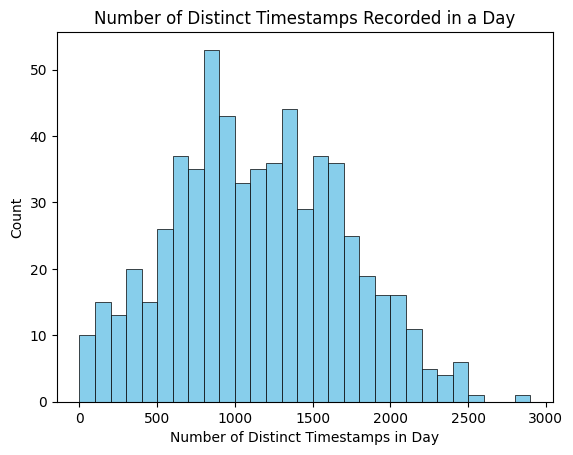

In [51]:
val_counts = rt2["Timestamp"].dt.date.value_counts()
plt.hist(val_counts.values, bins=np.arange(0, 3000, 100), color='skyblue', edgecolor='black', linewidth=0.5)
plt.xlabel("Number of Distinct Timestamps in Day")
plt.ylabel("Count")
plt.title("Number of Distinct Timestamps Recorded in a Day")

In [72]:
val_counts

Timestamp
2024-05-29    2883
2025-06-23    2566
2024-06-10    2478
2024-07-29    2464
2025-07-21    2461
              ... 
2024-01-20      55
2023-10-03      48
2025-12-24      46
2024-03-16      25
2024-01-27      22
Name: count, Length: 621, dtype: int64

Text(0.5, 1.0, 'Number of Tasks Performed by a Worker in a Day')

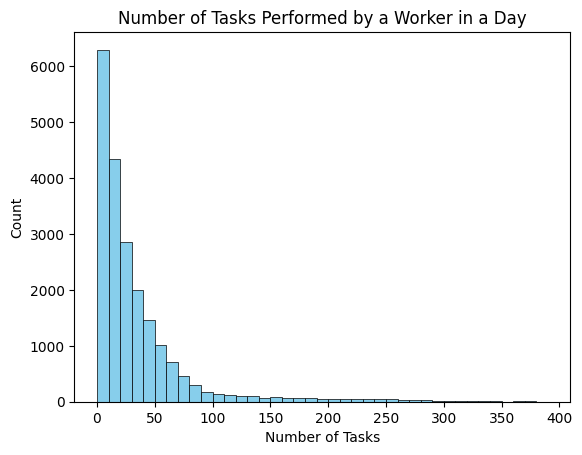

In [65]:
df = rt2.copy()
df["Date"] = df["Timestamp"].dt.date
df = df.loc[:, ["ActivityCode", "UserID", "Date"]]
result = df.groupby(["UserID", "Date"]).count().reset_index()
plt.hist(result["ActivityCode"], bins=np.arange(0, 400, 10), color='skyblue', edgecolor='black', linewidth=0.5)
plt.xlabel("Number of Tasks")
plt.ylabel("Count")
plt.title("Number of Tasks Performed by a Worker in a Day")

,UserID,ActivityCode
Date,,
2023-10-03,8,8
2023-10-04,28,28
2023-10-05,37,37
2023-10-06,37,37
2023-10-07,17,17
...,...,...
2025-12-24,11,11
2025-12-29,36,36
2025-12-30,31,31


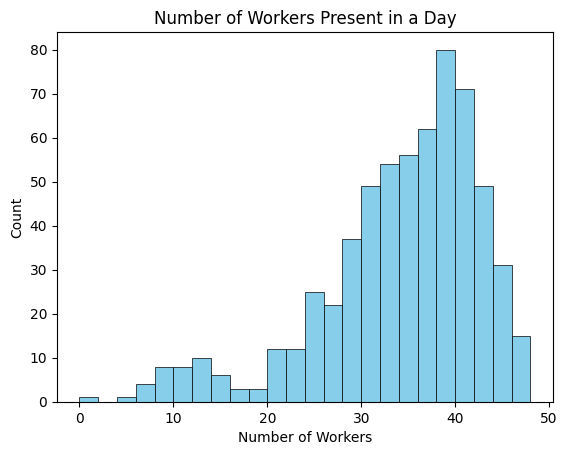

In [71]:
result = df.groupby(["UserID", "Date"]).count().reset_index().groupby("Date").count()
plt.hist(result["UserID"], bins=np.arange(0, 50, 2), color='skyblue', edgecolor='black', linewidth=0.5)
plt.xlabel("Number of Workers")
plt.ylabel("Count")
plt.title("Number of Workers Present in a Day")
result

In [16]:
counts = rt2.groupby("AssignmentID")[["UserID"]].count().reset_index().groupby("UserID").count()
counts["AssignmentID"] / sum(counts["AssignmentID"])

UserID
1     0.753217
2     0.123590
3     0.051053
4     0.025061
5     0.014101
6     0.008510
7     0.005538
8     0.003938
9     0.002754
10    0.001973
11    0.001632
12    0.001340
13    0.001083
14    0.000946
15    0.000779
16    0.000707
17    0.000582
18    0.000471
19    0.000450
20    0.000401
21    0.000285
22    0.000267
23    0.000218
24    0.000178
25    0.000151
26    0.000114
27    0.000134
28    0.000063
29    0.000093
30    0.000065
31    0.000035
32    0.000039
33    0.000032
34    0.000032
35    0.000030
36    0.000023
37    0.000016
38    0.000007
39    0.000025
40    0.000009
41    0.000002
42    0.000025
43    0.000007
44    0.000002
45    0.000005
47    0.000002
48    0.000002
53    0.000002
55    0.000002
56    0.000002
58    0.000002
59    0.000002
81    0.000002
Name: AssignmentID, dtype: float64

In [36]:
work1234 = ["1.0", "2.0", "3.0", "4.0"]
products_df = pd.DataFrame()
for wc in work1234:
    sub_df = rt[rt["WorkCode"] == wc]
    top_prods = sub_df.groupby("ProductID")["UserID"].count().reset_index().sort_values("UserID", ascending=False).iloc[:10, :]
    top_prods["WorkCode"] = wc
    products_df = pd.concat([products_df, top_prods])

products_df["ProductID"].value_counts()

ProductID
12148    1
14978    1
18927    1
13230    1
17664    1
11523    1
15438    1
13234    1
14180    1
13662    1
11624    1
12171    1
13313    1
14875    1
12214    1
19474    1
24042    1
26686    1
11900    1
11661    1
24088    1
13175    1
26112    1
13136    1
26320    1
17389    1
25039    1
11510    1
11972    1
14036    1
26353    1
17070    1
12944    1
18425    1
23848    1
18920    1
11996    1
20856    1
24306    1
11700    1
Name: count, dtype: Int64

In [50]:
work56 = ["1.0" "2.0", "3.0", "4.0"]
products_df = pd.DataFrame()
for wc in work56:
    sub_df = rt[rt["WorkCode"] == wc]
    top_prods = sub_df.groupby("ProductID")["UserID"].count().reset_index().sort_values("UserID", ascending=False).iloc[:30, :]
    top_prods["WorkCode"] = wc
    products_df = pd.concat([products_df, top_prods])

products_df["ProductID"].value_counts().sum()

np.int64(60)

In [31]:
rt[rt["WorkCode"] == "1.0"]

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
2857,AssignmentOpen,135,1.0,4481566,<NA>,<NA>,2024-05-28 14:55:07.493,<NA>,2024-05-28 14:48:57.660,96572,...,199,10,<NA>,NaN,NaN,607,199,NaN,607:199,NaN
2865,AssignmentOpen,135,1.0,4481084,<NA>,<NA>,2024-05-28 15:07:59.357,<NA>,2024-05-28 15:07:57.317,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2880,AssignmentOpen,135,1.0,4480648,<NA>,<NA>,2024-05-28 15:29:10.097,<NA>,2024-05-28 15:29:08.023,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2881,AssignmentOpen,135,1.0,4480600,<NA>,<NA>,2024-05-28 15:29:11.767,<NA>,2024-05-28 15:29:10.097,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2913,AssignmentOpen,135,1.0,4482158,<NA>,<NA>,2024-05-28 16:06:09.437,<NA>,2024-05-28 16:06:03.830,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225180,AssignmentOpen,96,1.0,4513726,<NA>,<NA>,2024-06-10 17:02:52.297,<NA>,2024-06-10 17:00:15.170,99382,...,541,10,<NA>,NaN,NaN,604,541,NaN,604:541,NaN
225181,AssignmentOpen,96,1.0,4513418,<NA>,<NA>,2024-06-10 17:02:54.240,<NA>,2024-06-10 17:02:52.297,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225183,AssignmentOpen,96,1.0,4513760,<NA>,<NA>,2024-06-10 17:02:57.713,<NA>,2024-06-10 17:02:55.813,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225201,AssignmentOpen,96,1.0,4513058,<NA>,<NA>,2024-06-10 17:18:50.980,<NA>,2024-06-10 17:14:26.977,100067,...,115,20,<NA>,NaN,NaN,605,115,NaN,605:115,NaN


In [42]:
import plotly.express as px

def plot_gantt(user_id:int, date:str, start:int=0, num_tasks:int=30, jitter:float=0.5):
    df_filtered = rt2[(rt2["UserID"] == user_id) & (rt2["Timestamp"].dt.date == pd.to_datetime(date).date())]
    df_start_end = df_filtered.groupby(["AssignmentID", "ActivityCode"]).agg({"Timestamp": [np.min, np.max]})
    df_start_end.columns = df_start_end.columns.droplevel(0)
    df_start_end = df_start_end.sort_values("min", ascending=True).iloc[start:start+num_tasks].reset_index()
    df_start_end["max"] = df_start_end["max"] + pd.to_timedelta(jitter, unit='m')
    fig = px.timeline(df_start_end, x_start="min", x_end="max", y="AssignmentID", color="ActivityCode", color_discrete_sequence=["red", "blue"])
    fig.update_yaxes(autorange="reversed")
    fig.update_layout(title_text="User" + f"{user_id}" +  " " + f"{date}" +  " " + f"First {num_tasks} UoW Gantt Chart")
    fig.show()

In [26]:
rt2[rt2["UserID"] == "102"]["Timestamp"].dt.date.value_counts()

Timestamp
2025-02-14    85
2024-06-28    39
2023-11-21    33
2024-02-29    29
2024-06-19    26
              ..
2025-09-11     1
2025-10-23     1
2025-10-27     1
2025-11-19     1
2025-12-18     1
Name: count, Length: 243, dtype: int64

In [44]:
plot_gantt("102", "2025-02-14", 20, 50, 0.5)